In [86]:
from flonacomldft.gaussian_utils import MoG
import matplotlib.pyplot as plt
import numpy as np

In [87]:
#def gaussian2d(xy, x0, y0, sigma_xx, sigma_xy, sigma_yx, sigma_yy, A):
#    #x, y = xy
#    return A * np.exp(-0.5 * ( (xy[0]-x0)*( (sigma_xx)*(xy[0]-x0) + sigma_xy*(xy[0]-x0) ) + 
#                                 (xy[1]-y0)*( (sigma_yx)*(xy[1]-x0) + sigma_yy*(xy[1]-y0) ) ) )

def gaussian2d(XY, x0, y0, sigma_xx, sigma_xy, sigma_yx, sigma_yy, A):
    XY = XY.T
    dx = XY[0] - x0
    dy = XY[1] - y0
    covariance_xx = sigma_xx * dx
    covariance_xy = sigma_xy * dx
    covariance_yx = sigma_yx * dy
    covariance_yy = sigma_yy * dy
    exponent = -0.5 * (covariance_xx * dx + covariance_xy * dy + covariance_yx * dx + covariance_yy * dy)
    return A * np.exp(exponent)


In [88]:
normal_dist_params = np.array([0, 0, 1, 0, 0, 1, 1])

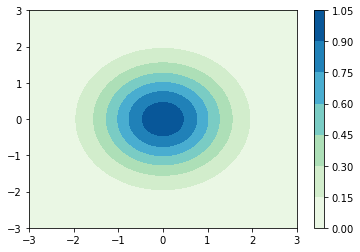

In [89]:
#write a grid space

n_points = 100

x = np.linspace(-3, 3, n_points)
y = np.linspace(-3, 3, n_points)
grid = np.meshgrid(x, y)
xys = np.stack(grid).reshape(2, n_points ** 2).T

#Z = np.array([gaussian2d(xy, *normal_dist_params) for xy in xys])
z = gaussian2d(xys, *normal_dist_params)

plt.contourf(x, y, z.reshape(100, 100), cmap='GnBu')
plt.gca().set_aspect('auto')
plt.colorbar()


In [90]:
from flonacomldft.utils.io_utils import get_path
import numpy as np
from scipy.optimize import curve_fit
from ase.units import kB

file = get_path()+'/unrotated_300.txt'

In [91]:
C_line = np.loadtxt(file, usecols=0)
R_line = np.loadtxt(file, usecols=1)
F_line = np.loadtxt(file, usecols=2)

bins = 401

C_grid = C_line.reshape(bins, bins)
R_grid = R_line.reshape(bins, bins)
F_grid = F_line.reshape(bins, bins)

T = 300
P_line = np.exp(-F_line/(kB*T))
P_grid = P_line.reshape(bins, bins)

In [92]:
xrange_is0 = [290,370]
yrange_is0 = [90,190]

C_is0 = C_grid[xrange_is0[0]:xrange_is0[1], yrange_is0[0]:yrange_is0[1]]
R_is0 = R_grid[xrange_is0[0]:xrange_is0[1], yrange_is0[0]:yrange_is0[1]]
F_is0 = F_grid[xrange_is0[0]:xrange_is0[1], yrange_is0[0]:yrange_is0[1]]
P_is0 = P_grid[xrange_is0[0]:xrange_is0[1], yrange_is0[0]:yrange_is0[1]]

In [93]:
xrange_is1 = [150,220]
yrange_is1 = [170,275]

C_is1 = C_grid[xrange_is1[0]:xrange_is1[1], yrange_is1[0]:yrange_is1[1]]
R_is1 = R_grid[xrange_is1[0]:xrange_is1[1], yrange_is1[0]:yrange_is1[1]]
F_is1 = F_grid[xrange_is1[0]:xrange_is1[1], yrange_is1[0]:yrange_is1[1]]
P_is1 = P_grid[xrange_is1[0]:xrange_is1[1], yrange_is1[0]:yrange_is1[1]]

In [94]:
# fig = plt.figure(figsize=(6, 6))
# ax = fig.gca(projection='3d')
# ax.plot_surface(C_is0, R_is0, P_is0, cmap='plasma')
# cset = ax.contourf(C_is0, R_is0, P_is0, zdir='z', offset=-4, cmap='plasma')
# ax.view_init(elev=5, azim=145-180)
# plt.colorbar(cset)

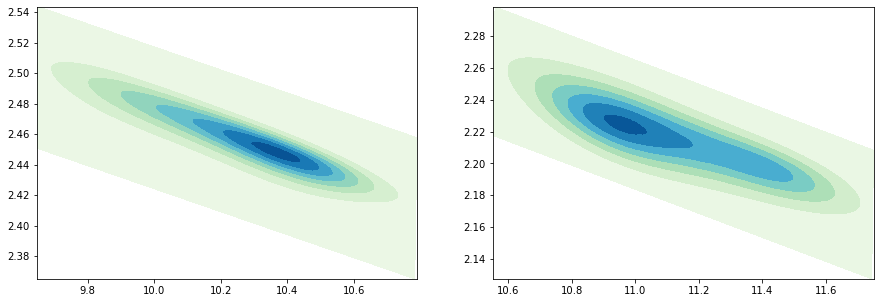

In [95]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].contourf(C_is0, R_is0, P_is0, cmap='GnBu')
axs[1].contourf(C_is1, R_is1, P_is1, cmap='GnBu')
plt.gca().set_aspect('auto')

In [96]:
C_is0_line = C_is0.reshape(-1)
R_is0_line = R_is0.reshape(-1)
F_is0_line = F_is0.reshape(-1)
P_is0_line = P_is0.reshape(-1)

C_is1_line = C_is1.reshape(-1)
R_is1_line = R_is1.reshape(-1)
F_is1_line = F_is1.reshape(-1)
P_is1_line = P_is1.reshape(-1)

In [97]:
#ind_is0 = (P_is0_line > 2.6e44)

#plt.scatter(C_is0_line[ind_is0], R_is0_line[ind_is0], c=P_is0_line[ind_is0], cmap='GnBu')
#plt.colorbar()

In [98]:
# ind = (P_line > 2.6e44)

# plt.scatter(C_line[ind], R_line[ind], c=P_line[ind], cmap='GnBu')
# plt.colorbar()
# plt.gca().set_aspect('auto')

/tmp/ipykernel_550787/540344587.py:24: UserWarning: The following kwargs were not used by contour: 'linestyle'
  ax[0].contour(x, y, z.reshape(n_points, n_points), colors='k', linestyle='--', linewidths=0.3)


array([ 1.02780425e+01,  2.45467097e+00,  9.61212303e+01,  4.49457582e+04,
       -4.28999489e+04,  1.26042674e+04,  4.09510568e+45])

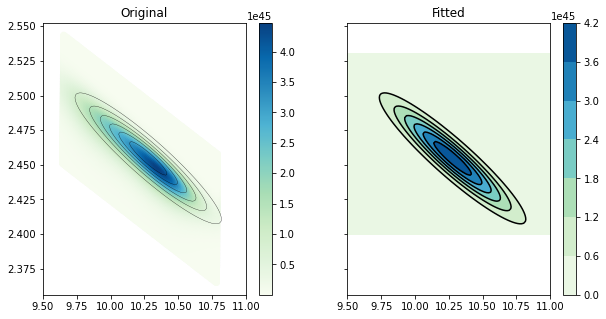

In [99]:
#data = np.stack([C_line[ind], R_line[ind], P_line[ind]], axis=1)
data = np.stack([C_is0_line, R_is0_line, P_is0_line], axis=1)
#data = np.stack([C_is0_line[ind_is0], R_is0_line[ind_is0], P_is0_line[ind_is0]], axis=1)

xy = data[:, :2]
z = data[:, 2]

#params = np.array([10.4, 2.4, 51, 0, -200.0, 5952, 1e45]) #THIS PARAMETERS FIT THE gaussian2d but covmatrix is non-positive
params = np.array([10.4, 2.4, 50, 1000, 1000, 5000, 1e45])

popt_0, pcov_0 = curve_fit(gaussian2d, xy, z, params)

n_points = 100
x = np.linspace(9.5, 11, n_points)
y = np.linspace(2.4, 2.53, n_points)
grid = np.meshgrid(x, y)
xys = np.stack(grid).reshape(2, n_points ** 2).T

z = gaussian2d(xys, *popt_0)

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
#ax[0].scatter(C_line[ind], R_line[ind], c=P_line[ind], cmap='GnBu')
ax[0].scatter(C_is0_line, R_is0_line, c=P_is0_line, cmap='GnBu')
ax[0].contour(x, y, z.reshape(n_points, n_points), colors='k', linestyle='--', linewidths=0.3)
fig.colorbar(ax[0].scatter(C_is0_line, R_is0_line, c=P_is0_line, cmap='GnBu'), ax=ax[0])
ax[0].set_title('Original')

ax[1].contourf(x, y, z.reshape(n_points, n_points), cmap='GnBu') 
ax[1].contour(x, y, z.reshape(n_points, n_points), colors='k')
ax[1].set_title('Fitted')
fig.colorbar(ax[1].contourf(x, y, z.reshape(n_points, n_points), cmap='GnBu'), ax=ax[1])
popt_0

/tmp/ipykernel_550787/813078520.py:22: UserWarning: The following kwargs were not used by contour: 'linestyle'
  ax[0].contour(x, y, z.reshape(n_points, n_points), colors='k', linestyle='--', linewidths=0.3)


array([ 1.02780425e+01,  2.45467097e+00,  9.61212303e+01,  4.49457582e+04,
       -4.28999489e+04,  1.26042674e+04,  4.09510568e+45])

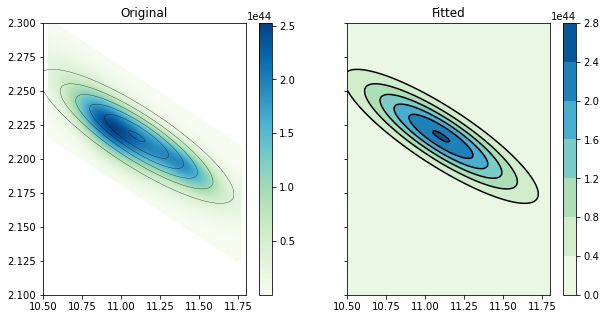

In [100]:
#data = np.stack([C_line[ind], R_line[ind], P_line[ind]], axis=1)
data = np.stack([C_is1_line, R_is1_line, P_is1_line], axis=1)

xy = data[:, :2]
z = data[:, 2]

params = np.array([11.1, 2.2, 18, 0.0, 196.0, 2884, 2e44])

popt_1, pcov_1 = curve_fit(gaussian2d, xy, z, params)

n_points = 100
x = np.linspace(10.5, 11.8, n_points)
y = np.linspace(2.1, 2.3, n_points)
grid = np.meshgrid(x, y)
xys = np.stack(grid).reshape(2, n_points ** 2).T

z = np.array([gaussian2d(xy, *popt_1) for xy in xys])

fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)
#ax[0].scatter(C_line[ind], R_line[ind], c=P_line[ind], cmap='GnBu')
ax[0].scatter(C_is1_line, R_is1_line, c=P_is1_line, cmap='GnBu')
ax[0].contour(x, y, z.reshape(n_points, n_points), colors='k', linestyle='--', linewidths=0.3)
fig.colorbar(ax[0].scatter(C_is1_line, R_is1_line, c=P_is1_line, cmap='GnBu'), ax=ax[0])

ax[0].set_title('Original')

ax[1].contourf(x, y, z.reshape(n_points, n_points), cmap='GnBu') 
ax[1].contour(x, y, z.reshape(n_points, n_points), colors='k')
ax[1].set_title('Fitted')
fig.colorbar(ax[1].contourf(x, y, z.reshape(n_points, n_points), cmap='GnBu'), ax=ax[1])

popt_0

In [101]:
# delete extra info using ind like the first time

## Adaptive

In [102]:
import scipy.stats as stats

In [103]:
import torch

lims = {'x_min':8.5, 'x_max':12, 'y_min':2.40, 'y_max':2.5}
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_plot(ax, n_points, target_log_prob, prop_log_prob=None, lims=lims):
    
    x_range = torch.linspace(lims['x_min'], lims['x_max'], n_points, device=device)

    if lims['y_min'] is None:
        y_range = x_range.clone()
    else:
        y_range = torch.linspace(lims['y_min'], lims['y_max'], n_points, device=device)

    grid = torch.meshgrid(x_range, y_range)
    xys = torch.stack(grid).reshape(2, n_points ** 2).T.to(device)

    Us_target = target_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

    if ax is None:
        plt.figure()
    else:
        plt.sca(ax)
    #plt.axis('off')

    plt.contourf(x_range, y_range, np.exp(Us_target)
    # np.log( - Us_target + Us_target.max() + 1)
    , 10, cmap='GnBu')
    ax.set_aspect('equal')

    if prop_log_prob is not None:
        Us_prop = prop_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

        plt.contour(x_range, y_range, np.exp(Us_prop), 10, colors='k', linestyles=':', alpha=0.5)

In [104]:
def gaussian2d(XY, x0, y0, sigma_xx, sigma_xy, sigma_yx, sigma_yy, A):
    XY = XY.T
    XY = torch.tensor(XY, dtype=torch.float64, device=device)
    dx = XY[0] - x0
    dy = XY[1] - y0
    covariance_xx = sigma_xx * dx
    covariance_xy = sigma_xy * dx
    covariance_yx = sigma_yx * dy
    covariance_yy = sigma_yy * dy
    exponent = -0.5 * (covariance_xx * dx + covariance_xy * dy + covariance_yx * dx + covariance_yy * dy)
    return A * torch.exp(exponent)

In [105]:
class TargetGaussian:
    def __init__(self, mean, cov, norm, kB=kB, T=300):
        self.kB = kB
        self.T = T
        self.norm = norm
        self.mean = mean
        self.cov = cov
        self.inv_cov = np.linalg.inv(cov)
        self.popt = np.hstack([self.mean.flatten(), self.inv_cov.flatten(), self.norm])
    
    def sample(self, n_samples):
        samples = np.random.multivariate_normal(self.mean, self.cov, n_samples)
        return torch.tensor(samples, dtype=torch.float64)

    def prob(self, x):
        return torch.tensor(gaussian2d(x, *self.popt)).detach()

    def log_prob(self, x):
        return torch.log(gaussian2d(x, *self.popt)).detach()
    
    def U(self, x):
        return -self.log_prob(x)*(self.T*self.kB)

In [106]:
def from_popt_to_gauss_params(popt):
    means = popt[:2]
    inv_cov = popt[2:-1].reshape(2, 2)
    cov = np.linalg.inv(inv_cov)
    norm = popt[-1]
    return means, cov, norm

In [107]:
popt_gen = np.array([10.27, 2.45, 500, -10, 10000, 500, 1e44])
mean_gen, cov_gen, norm_gen = from_popt_to_gauss_params(popt_gen)

A = 1/15349329
a = 140/1705481
b = 6821/15349329
c = -781/1705481
d = 961/15349329

cov_gen  = np.array([[a, b], [c, d]])

generator = TargetGaussian(mean_gen, cov_gen, norm_gen)

mean_0, cov_0, norm_0 = from_popt_to_gauss_params(popt_0)

print(cov_0)

cov_0[1, 0] = 0
#cov_0[0, 1] = cov_0[0, 0]
#cov_0[0, 0] = cov_0[1, 1]
#cov_0[1, 1] = cov_0[0, 1]
cov_0[0, 1] = 0

print(cov_0)

target_0 = TargetGaussian(mean_0, cov_0, norm_0)

[[ 6.53279943e-06 -2.32954138e-05]
 [ 2.22350696e-05  4.98196920e-08]]
[[6.53279943e-06 0.00000000e+00]
 [0.00000000e+00 4.98196920e-08]]


In [108]:
np.linalg.eigvals(cov_0)

array([6.53279943e-06, 4.98196920e-08])

In [109]:
stats.multivariate_normal(mean_0, cov_0)

In [110]:
A = np.array([
    [1, 0, 0, 0, popt_0[2]],
    [0, 1, 0, 0, popt_0[3]],
    [0, 0, 1, 0, popt_0[4]],
    [0, 0, 0, 1, popt_0[5]],
    [0, 0, 0, 0, 1-(popt_0[2]*popt_0[3])-(popt_0[3]*popt_0[4])]
])

B = np.zeros(5)
             

np.linalg.solve(A, B), (1/(1-(popt_0[2]*popt_0[3])-(popt_0[3]*popt_0[4])))*popt_0[4]

(array([0., 0., 0., 0., 0.]), -2.229900356710417e-05)

In [111]:
target_0.inv_cov, target_0.cov

(array([[  153073.73354647,        0.        ],
        [       0.        , 20072384.22244326]]),
 array([[6.53279943e-06, 0.00000000e+00],
        [0.00000000e+00, 4.98196920e-08]]))

In [112]:
cov_0, cov_gen

(array([[6.53279943e-06, 0.00000000e+00],
        [0.00000000e+00, 4.98196920e-08]]),
 array([[ 8.20882789e-05,  4.44384246e-04],
        [-4.57935327e-04,  6.26086000e-05]]))

In [113]:
#from flonacomldft.gaussian_utils import MoG

#target = MoG(torch.tensor([mean_gen]), torch.abs(torch.tensor([cov_gen])))

/tmp/ipykernel_550787/1040167257.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XY = torch.tensor(XY, dtype=torch.float64, device=device)


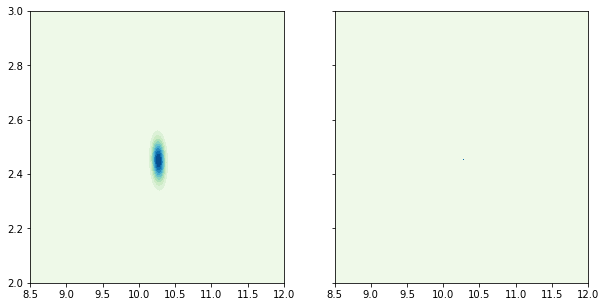

In [114]:
lims = {'x_min':8.5, 'x_max':12, 'y_min':2, 'y_max':3}

fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(10, 5))
set_plot(ax[0], 1000, generator.log_prob, None, lims)
plt.gca().set_aspect('auto')
set_plot(ax[1], 1000, target_0.log_prob, None, lims)
plt.gca().set_aspect('auto')

In [115]:
generator.cov

array([[ 8.20882789e-05,  4.44384246e-04],
       [-4.57935327e-04,  6.26086000e-05]])

/tmp/ipykernel_550787/812703209.py:12: RuntimeWarning: covariance is not positive-semidefinite.
  samples = np.random.multivariate_normal(self.mean, self.cov, n_samples)
/tmp/ipykernel_550787/1040167257.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XY = torch.tensor(XY, dtype=torch.float64, device=device)
/tmp/ipykernel_550787/812703209.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(gaussian2d(x, *self.popt)).detach()


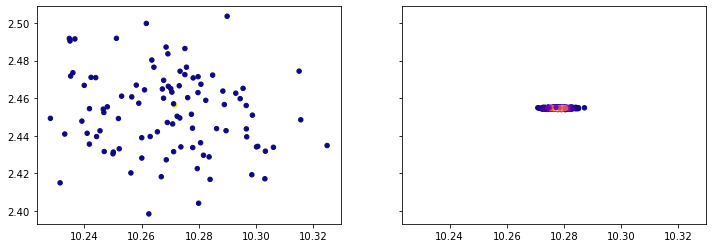

In [116]:
samples_gen = generator.sample(100)
samples_0 = target_0.sample(1000)

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)
ax[0].scatter(samples_gen[:, 0], samples_gen[:, 1], c=target_0.prob(samples_gen), cmap='plasma', s=20)
ax[1].scatter(samples_0[:, 0], samples_0[:, 1], c=target_0.prob(samples_0), cmap='plasma', s=20)

/tmp/ipykernel_550787/812703209.py:12: RuntimeWarning: covariance is not positive-semidefinite.
  samples = np.random.multivariate_normal(self.mean, self.cov, n_samples)
/tmp/ipykernel_550787/1040167257.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XY = torch.tensor(XY, dtype=torch.float64, device=device)
/tmp/ipykernel_550787/812703209.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(gaussian2d(x, *self.popt)).detach()


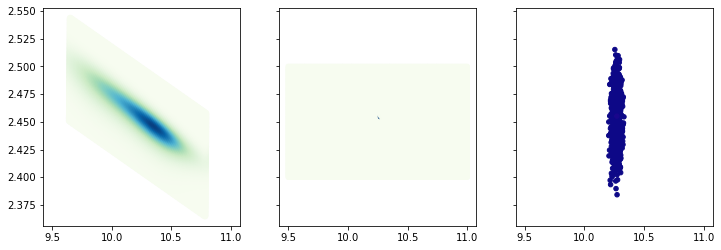

In [117]:
samples_0 = generator.sample(1000)

x = torch.linspace(9.5, 11, n_points)
y = torch.linspace(2.4, 2.5, n_points)
grid = torch.meshgrid(x, y)
xys = torch.stack(grid).reshape(2, n_points ** 2).T

#print(xys)

z = target_0.prob(xys)

xys

fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)
#plt.contourf(x.detach().numpy(), y.detach().numpy(), z.reshape(n_points, n_points).detach().numpy(), cmap='GnBu')
#plt.contour(x.detach().numpy(), y.detach().numpy(), z.reshape(n_points, n_points).detach().numpy(), cmap='GnBu')
ax[0].scatter(C_is0_line, R_is0_line, c=P_is0_line, cmap='GnBu')
ax[1].scatter(xys[:, 0].detach().numpy(), xys[:,1].detach().numpy(), c=z.detach().numpy(), cmap='GnBu', s=20)
#ax[0].scatter(samples_0[:, 0], samples_0[:, 1], c=target_0.prob(samples_0), cmap='plasma', s=20)
ax[2].scatter(samples_0[:, 0], samples_0[:, 1], c=target_0.prob(samples_0), cmap='plasma', s=20)
#plt.colorbar()

In [118]:
n_samples = 100

generator_samples = generator.sample(n_samples)
#generator_us = torch.tensor([target_0.U(sample) for sample in generator_samples])
generator_us = torch.tensor([generator.U(sample) for sample in generator_samples])
id_mode = torch.zeros(n_samples)
dataset = torch.cat([generator_samples.T, generator_us.reshape(1, -1), id_mode.reshape(1, -1)]).T

# use mean to center data
dataset[:,:2] = dataset[:, :2] # - torch.tensor([mean_0])

train = dataset[:int(0.8 * len(dataset))]
test = dataset[int(0.8 * len(dataset)):] 

/tmp/ipykernel_550787/812703209.py:12: RuntimeWarning: covariance is not positive-semidefinite.
  samples = np.random.multivariate_normal(self.mean, self.cov, n_samples)
/tmp/ipykernel_550787/1040167257.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XY = torch.tensor(XY, dtype=torch.float64, device=device)


In [119]:
#target_energy = lambda x: target_0.U(x)
target_energy = lambda x: generator.U(x)
mlp_dic = {'model': target_energy}

In [120]:
from flonacomldft.models.real_nvp import RealNVP_MLP
from flonacomldft.train_flow_from_data import train_flow

In [121]:
torch.cov(train[:, :2].T).float()

tensor([[ 4.5801e-04, -3.2031e-05],
        [-3.2031e-05,  5.1998e-04]])

In [122]:
n_blocks = 2
hidden_dim = 16
hidden_depth = 4

model = RealNVP_MLP(2,
                    n_blocks=n_blocks,
                    block_depth=1,
                    init_weight_scale=1e-1,
                    base_cov=torch.cov(train[:, :2].T).float(),
                    hidden_dim=hidden_dim,
                    hidden_depth=hidden_depth,
                    device=device,
                    )

In [123]:
train = train.type(torch.float32)
test = test.type(torch.float32)

In [134]:
n_iter = 5000 #10000

In [135]:
flow_dic = train_flow(
    model,
    train,
    test,
    dim=2,
    n_iter=n_iter,
    lr=1e-3,
    use_scheduler=False,
    step_schedule=int(n_iter/3),
    save_splits=10,
    grad_clip=1e4,
    with_tqdm=False,
    compute_part_ratio=True,
    energy_type='mlp',
    mlp_model=mlp_dic['model'],
    n_prop=1000,
    path='',
)

t=0.0e+00 	 loss: -2.33	Gd: 1e+01	lr: 1.00e-03	part ratio: 9.54e-03


/tmp/ipykernel_550787/1040167257.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XY = torch.tensor(XY, dtype=torch.float64, device=device)


t=5.0e+02 	 loss: -3.68	Gd: 3e+00	lr: 1.00e-03	part ratio: 3.84e-02
t=1.0e+03 	 loss: -4.18	Gd: 7e+01	lr: 1.00e-03	part ratio: 1.30e-01
t=1.5e+03 	 loss: -4.35	Gd: 3e+00	lr: 1.00e-03	part ratio: 1.16e-01
t=2.0e+03 	 loss: -4.42	Gd: 2e+00	lr: 1.00e-03	part ratio: 1.46e-01
t=2.5e+03 	 loss: -4.46	Gd: 6e+00	lr: 1.00e-03	part ratio: 1.87e-01
t=3.0e+03 	 loss: -4.49	Gd: 7e-01	lr: 1.00e-03	part ratio: 2.32e-01
t=3.5e+03 	 loss: -4.50	Gd: 6e+01	lr: 1.00e-03	part ratio: 2.36e-02
t=4.0e+03 	 loss: -4.53	Gd: 3e+00	lr: 1.00e-03	part ratio: 2.27e-01
t=4.5e+03 	 loss: -4.52	Gd: 9e+01	lr: 1.00e-03	part ratio: 2.87e-01


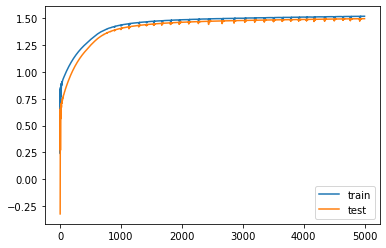

In [140]:
plt.plot(np.log(abs(flow_dic['losses'][0])), label='train')
plt.plot(np.log(abs(flow_dic['losses'][1])), label='test')
plt.legend()

In [141]:
model = flow_dic['model']

In [142]:
flow_samples = model.sample(100) #+ torch.tensor(generator.mean).reshape(1, -1)
prob_samples = generator.prob(flow_samples)

/tmp/ipykernel_550787/1040167257.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XY = torch.tensor(XY, dtype=torch.float64, device=device)
/tmp/ipykernel_550787/812703209.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(gaussian2d(x, *self.popt)).detach()


/tmp/ipykernel_550787/1040167257.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XY = torch.tensor(XY, dtype=torch.float64, device=device)


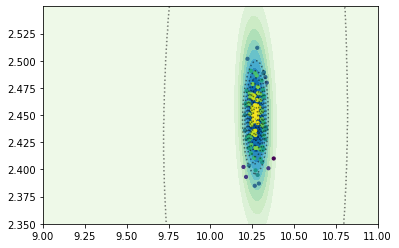

In [143]:
lims = {'x_min':9, 'x_max':11, 'y_min':2.35, 'y_max':2.55}

#plt.scatter(C_is0_line, R_is0_line, c=P_is0_line, cmap='GnBu')
flowlogprob = lambda x: -flow_dic['model'].nll(x)
fig, ax = plt.subplots(1, 1)
set_plot(ax, 1000, generator.log_prob, flowlogprob, lims)
ax.scatter(flow_samples[:, 0].detach().numpy(), flow_samples[:, 1].detach().numpy(), c=prob_samples, s=10)
plt.gca().set_aspect('auto')
#plt.xlim(9, 11)
#plt.ylim(2.4, 2.5)

In [130]:
n_samples = 100
#target_samples = target_0.sample(n_samples)
target_samples = generator.sample(n_samples)
target_samples
#target_us = target_0.U(target_samples)
target_us = generator.U(target_samples)
target_us
id_mode = torch.zeros(n_samples)
id_mode
init = torch.cat([target_samples.T, target_us.reshape(1, -1), id_mode.reshape(1, -1)]).T
n_chains = init.shape[0]
n_steps = 100

/tmp/ipykernel_550787/812703209.py:12: RuntimeWarning: covariance is not positive-semidefinite.
  samples = np.random.multivariate_normal(self.mean, self.cov, n_samples)
/tmp/ipykernel_550787/1040167257.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XY = torch.tensor(XY, dtype=torch.float64, device=device)


In [131]:
from flonacomldft.sampling import run_metropolis

In [132]:
init = init.type(torch.float32)

In [133]:
_ = run_metropolis(flow_dic['model'], init, n_chains, n_steps, dim=2,
                   energy_type='mlp', mlp_models=[mlp_dic['model']], scheduler=10)

/tmp/ipykernel_550787/1040167257.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XY = torch.tensor(XY, dtype=torch.float64, device=device)


step: 0 	 acc: 0.34
step: 10 	 acc: 0.25
step: 20 	 acc: 0.32
step: 30 	 acc: 0.31
step: 40 	 acc: 0.30
step: 50 	 acc: 0.26
step: 60 	 acc: 0.25
step: 70 	 acc: 0.37
step: 80 	 acc: 0.34
step: 90 	 acc: 0.35


In [48]:
from flonacomldft.full_adaptive_sampling import adaptive_sampling
from flonacomldft.full_adaptive_sampling import get_weights

In [49]:
flow_hyperparams = {'n_iter': 10,
    'lr': 2.5e-4,
    'use_scheduler': False,
    'step_schedule': 100,
    'save_splits': 10,
    'grad_clip': 1e4}

In [50]:
n_runs = 10
n_chains = 25
n_steps = 5

init_samples = generator.sample(n_chains)
init_us = generator.U(init_samples)
init_id_mode = torch.zeros(init_samples.shape[0])

print(init_id_mode)

init_mcmc = torch.cat([init_samples.T, init_us.reshape(1, -1), init_id_mode.reshape(1, -1)]).T

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.])


/tmp/ipykernel_550787/812703209.py:12: RuntimeWarning: covariance is not positive-semidefinite.
  samples = np.random.multivariate_normal(self.mean, self.cov, n_samples)
/tmp/ipykernel_550787/1040167257.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  XY = torch.tensor(XY, dtype=torch.float64, device=device)


In [51]:
full_train = torch.cat([train])
full_test = torch.cat([test])

flows_dic = [flow_dic]
mlps_dic = [mlp_dic]

In [52]:
full_train = full_train.type(torch.float32)
full_test = full_test.type(torch.float32)
init_mcmc = init_mcmc.type(torch.float32)

In [53]:
full_train[:, 3] = 0

In [54]:
#import os

In [55]:
#_ = adaptive_sampling(full_train, 
                        full_test,
                         init_mcmc, 
                         dim=2,
                         dict_flows_init=flows_dic,
                         dict_mlps_init=mlps_dic,
                         mixture=False,
                         flow_hyperparams=[flow_hyperparams],
                         n_runs=n_runs,
                         n_chains=n_chains,
                         n_steps=n_steps,
                         path='',
                         #path=os.getcwd(),
                         #dft_folder_name='',
                        )

IndentationError: unexpected indent (2296126450.py, line 2)